In [1]:
import ROOT
import emm

import numpy as np
import matplotlib.pyplot as plt

Welcome to JupyROOT 6.30/04
Top directory: /project01/ndcms/atownse2/ExponentialMixtureModel


In [2]:
# Get data
data_tree = emm.get_data(sort_and_index=True, tree=True)

x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 4000)
index=ROOT.RooRealVar("index", "index", 0, 0, 1e6)

data = ROOT.RooDataSet("data", "data", ROOT.RooArgSet(x, index), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


# Initial Conditions

Plotting raw_rate_0 vs raw_rate_1 on axes (0, 0)
Minimum NLL: 31030.826118550707
Best fit parameters: raw_rate_0              0.614000
raw_rate_1              1.422000
raw_rate_0_final        0.642178
raw_rate_1_final        1.535201
nll                 31030.826119
Name: 366, dtype: float64
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing dataset data
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::x
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::index
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGenericPdf::pdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooFormulaVar::weight_0
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::raw_weight_0
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::raw_weight_1
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooFormulaVar::weight_1
[#1] INFO:ObjectHandling -- RooWorkspace:

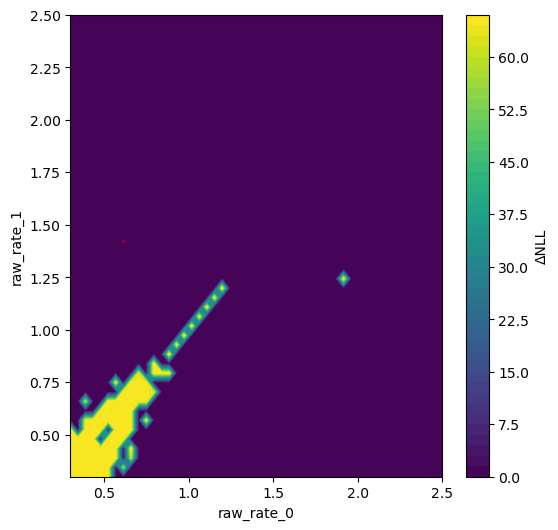

In [3]:
pset = {
    'raw_rate_0': (0.3, 2.5, 50),
    'raw_rate_1': (0.3, 2.5, 50),
}

model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))

df = emm.scan_parameters(
    model, data, pset,
    constant=False, # Not fixing parameters
    # use_condor=False, n_batches=8, cache_name="2D_grid_restarts", remake_cache=True,
    use_condor=True, n_batches=64, cache_name="2D_grid_restarts",# remake_cache=True,
)

fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False,)
print(f"Minimum NLL: {df['nll'].min()}")
print(f"Best fit parameters: {df.loc[df['nll'].idxmin()]}")

Text(0, 0.5, 'Density')

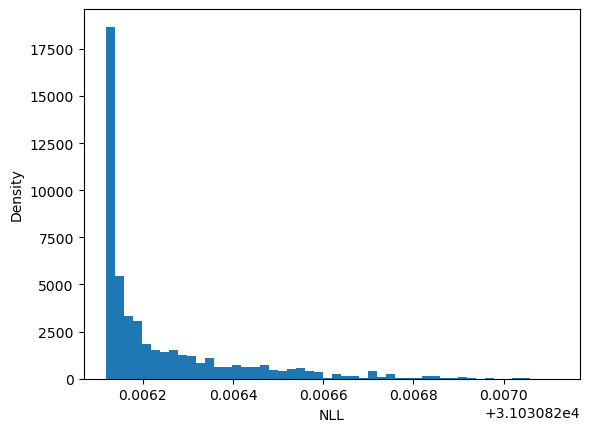

In [8]:
# Plot the distribution of the NLL
fig, ax = plt.subplots()
m = df['nll'].min()
n, bins, patches = ax.hist(df['nll'], range=(m, m+0.001), bins=50, density=True)
ax.set_xlabel("NLL")
ax.set_ylabel("Density")

Plotting raw_rate_0 vs raw_rate_1 on axes (0, 0)
Plotting raw_rate_0 vs raw_rate_2 on axes (1, 0)
Plotting raw_rate_1 vs raw_rate_2 on axes (1, 1)
Minimum NLL: 31030.826118544494
Best fit parameters: raw_rate_0              2.931000
raw_rate_1              1.338000
raw_rate_2              0.992000
raw_rate_0_final        1.535189
raw_rate_1_final        0.642176
raw_rate_2_final        1.535184
nll                 31030.826119
Name: 58827, dtype: float64
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing dataset data
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::x
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::index
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooGenericPdf::pdf
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooFormulaVar::weight_0
[#1] INFO:ObjectHandling -- RooWorkspace::import(ws) importing RooRealVar::raw_weight_0
[#1] INFO:ObjectHandling -- RooWorkspace::import(w

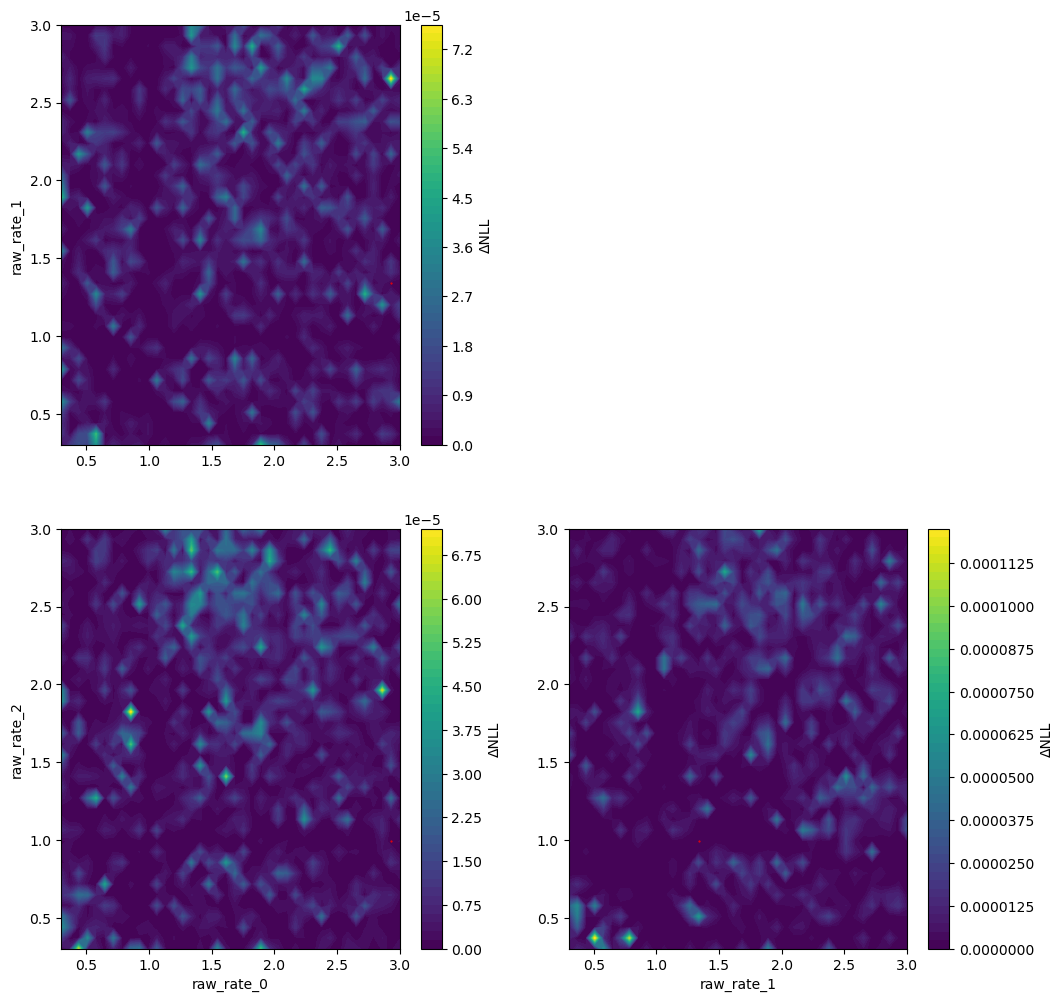

In [9]:
pset = {
    'raw_rate_0': (0.3, 3, 40),
    'raw_rate_1': (0.3, 3, 40),
    'raw_rate_2': (0.3, 3, 40),
}

model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))

df = emm.scan_parameters(
    model, data, pset,
    constant=False, # Not fixing parameters
    use_condor=True, n_batches=64, cache_name="3D_grid_restarts",# remake_cache=True,
)

fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False, worst_case=False)
print(f"Minimum NLL: {df['nll'].min()}")
print(f"Best fit parameters: {df.loc[df['nll'].idxmin()]}")

Text(0.5, 0, 'NLL')

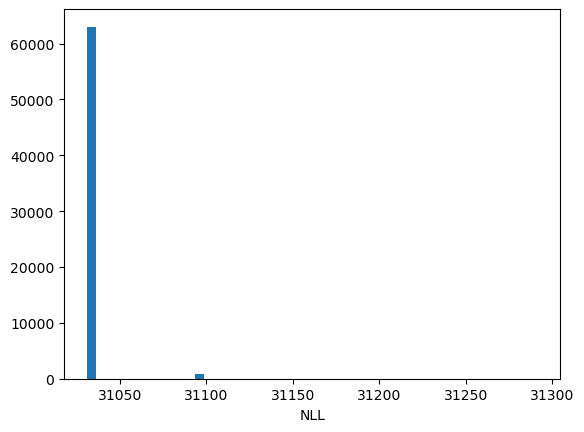

In [25]:
# Plot the distribution of the NLL
fig, ax = plt.subplots()
m = df['nll'].min()
n, bins, patches = ax.hist(
    df['nll'],
    # range=(m, m+0.005),
    # range=(31090, 31100),
    bins=50,
    # density=True
)
ax.set_xlabel("NLL")
# ax.set_ylabel("Density")

# Does it matter if we get stuck in a local minimum?

In [ ]:
# Use toys to estimate the NLL uncertainty due to data statistics
best_initial = emm.get_initial(2)
worst_initial = emm.get_initial(2, worst_case=True)

model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))
defaults = {param.GetName(): param.getVal() for param in model.params}

nll = model.pdf.createNLL(data)

# Get worst case nll
model.set_params(worst_initial)
model.pdf.fitTo(data)
nll_worst = model.pdf.createNLL(data)

# Gest best case nll
model.set_params(best_initial)
model.pdf.fitTo(data)
nll_best = model.pdf.createNLL(data)

# Generate toys and calculate the different in NLL between the best and worst initializations
n_toys = 100
nlls_global = []
nlls_local = []
for i in range(n_toys):
    toy = model.pdf.generate(ROOT.RooArgSet(x), data.numEntries())
    # nll = model.pdf.createNLL(toy)
    i_model = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x))
    i_model.set_params(initials)
    nll = i_model.pdf.createNLL(toy)
    fit_result = model.pdf.fitTo(toy)
    nlls.append(nll.getVal())

[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1500 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 31030.8264329726735
Edm   = 0.000312940379603826883
Nfcn  = 63
raw_rate_0	  = 0.642488	 +/-  0.0462667	(limited)
raw_rate_1	  = 1.53432	 +/-  0.111555	(limited)
raw_weight_1	  = 0.468091	 +/-  0.313356
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =         31078.554 Edm =       111.6694966 NCalls =     13
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31078.554
  Edm           : 111.6694966
  Internal parameters:	[     -1.413919205     -1.331732162                0]	
  Internal gradient  :	[     -4273.038154     -2052.252225     -124.4214169]	
  Internal covariance matrix:
[[  7.2800983e-06              0              0]
 [              0  2.5358314e-05              0]
 [              0              0    0.013368211]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1500
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =         31078.554 Edm =       111.6694966 NCalls =     13
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       31031.03427 Edm =     0.08373398663 NCalls =     21
Info in <Minuit2>: VariableMetri

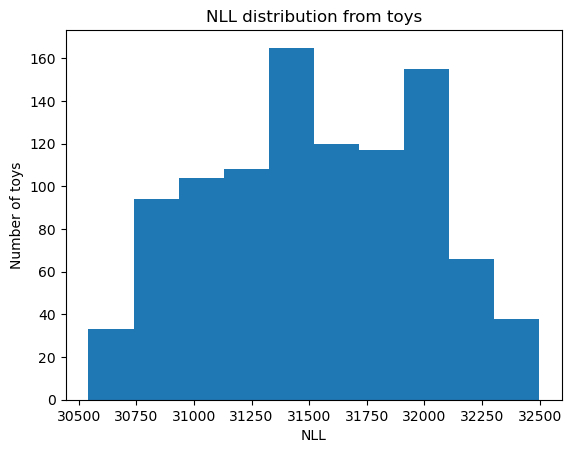

Mean NLL: 31528.323791429295
Std NLL: 458.28018022968115


In [60]:
# Plot the distribution of the nlls and print some statistics
plt.hist(nlls, bins=10)
plt.xlabel("NLL")
plt.ylabel("Number of toys")
plt.title("NLL distribution from toys")
plt.show()
print(f"Mean NLL: {np.mean(nlls)}")
print(f"Std NLL: {np.std(nlls)}")

In [71]:
initials = {
    'raw_rate_0': 1.295,
    'raw_rate_1': 0.584,
    'raw_rate_2': 1.579,
}

Fitted in 0.27 seconds
Fit status: 1, covQual: 2
NLL: 31030.826180829255


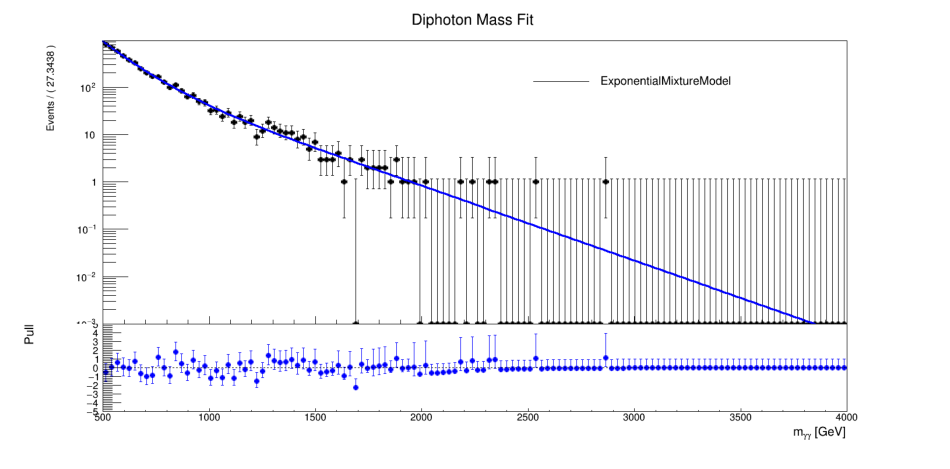

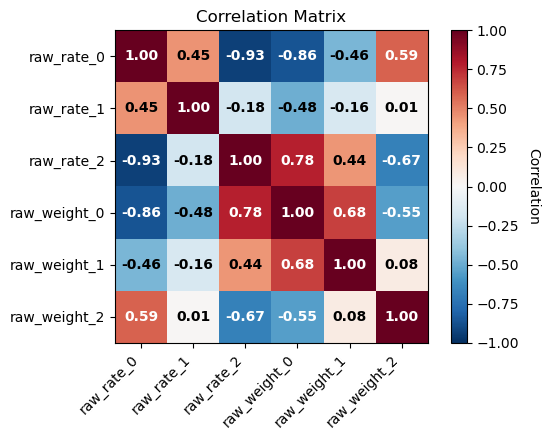

Model: ExponentialMixtureModel
raw_rate_0: 1.530329581253758 + 0.7748274869878724 -0.7748274869878724
raw_rate_1: 0.6424652615904565 + 0.0437016534572931 -0.0437016534572931
raw_rate_2: 1.5393061879656944 + 0.4085484059024824 -0.4085484059024824
raw_weight_0: -0.4761510537077296 + 1.983773058300441 -1.983773058300441
raw_weight_1: 0.04070545836416827 + 0.4851533559425973 -0.4851533559425973
raw_weight_2: 0.0390699146093036 + 0.7142082650646091 -0.7142082650646091
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
Minuit2Minimizer: Minimize with max-calls 3000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31030.8262682120876
Edm   = 0.000130469045032168343
Nfcn  = 228
raw_rate_0	  = 1.53008	 +/-  0.752886	(limited)
raw_rate_1	  = 0.642432	 +/-  0.0438732	(limited)
raw_rate_2	  = 1.53918	 +/-  0.396629	(limited)
raw_weight_0	  = -0.476669	 +/-  2

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31033.64251 Edm =       11.63841697 NCalls =     25
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31033.64251
  Edm           : 11.63841697
  Internal parameters:	[      -1.34270608     -1.417807385     -1.318813668                0                0                0]	
  Internal gradient  :	[     -298.4255575     -944.1618545      -234.668523     -10.66791122      27.68331513     -17.00606622]	
  Internal covariance matrix:
[[   5.947978e-05              0              0              0              0              0]
 [              0  9.9375845e-06              0              0              0              0]
 [              0              0  7.4802769e-05              0              0              0]
 [              0              0              0    0.089273361              0              0]
 [              0         

In [72]:
model = emm.ExponentialMixtureModel(x, 3, data_mean=data.mean(x))
model.set_params(initials)
emm.fit_and_plot(model, data, x)

In [19]:
# Add two events in the tail
data_copy = data.Clone()
# vals_to_add = [2500]*50
vals_to_add = np.random.normal(3800, 30, size=1)
for val in vals_to_add:
    x.setVal(val)
    index.setVal(data_copy.numEntries())
    data_copy.add(ROOT.RooArgSet(x, index))

print(f"Data entries (with tail events): {data_copy.numEntries()}")

Data entries (with tail events): 5037


[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1500 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 31049.2571975852516
Edm   = 0.000237665296036216451
Nfcn  = 96
raw_rate_0	  = 0.614666	 +/-  0.0470607	(limited)
raw_rate_1	  = 1.4924	 +/-  0.101591	(limited)
raw_weight_1	  = 0.643046	 +/-  0.313312
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 2500 convergence for edm < 1 

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =        31237.2856 Edm =       457.8696281 NCalls =     13
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31237.2856
  Edm           : 457.8696281
  Internal parameters:	[     -1.370461484     -1.287002218                0]	
  Internal gradient  :	[      9914.467111      2303.947489      196.4575105]	
  Internal covariance matrix:
[[  7.6514078e-06              0              0]
 [              0  0.00012079984              0]
 [              0              0    0.011352192]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1500
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =        31237.2856 Edm =       457.8696281 NCalls =     13
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =       31086.80484 Edm =       22.47867066 NCalls =     25
Info in <Minuit2>: VariableMetr

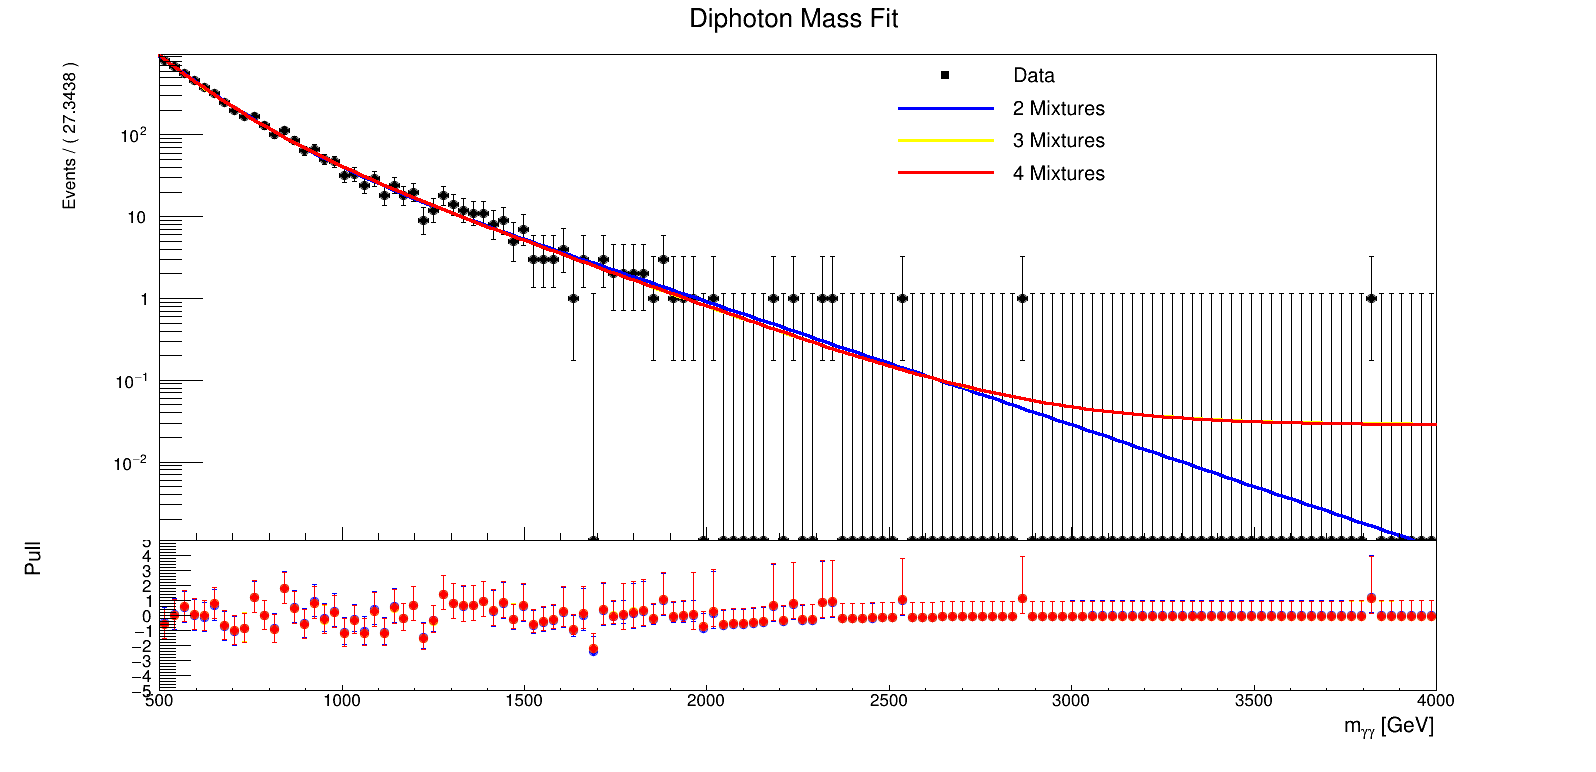

In [55]:
# model = emm.ExponentialMixtureModel(x, 3, data_mean=data_copy.mean(x))
models = [emm.ExponentialMixtureModel(x, k, data_mean=data_copy.mean(x)) for k in range(2, 5)]
model_labels = [f"{k} Mixtures" for k in range(2, 5)]
fit_results = [m.pdf.fitTo(data_copy, ROOT.RooFit.Save()) for m in models]
emm.plot_fits(data_copy, x, models, model_labels, fit_results,)
# model.set_params(initials)
# model.set_param('raw_rate_2', 0, constant=True)
# emm.fit_and_plot(model, data_copy, x)

Plotting raw_rate_0 vs raw_rate_1 on axes (0, 0)
[#[#1] INFO:1NumericIntegration]  -- INFORooRealIntegral::init(:ExponentialMixtureModel_Int[x]NumericIntegration) using numeric integrator  -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegratorRooRombergIntegrator to calculate Int to calculate Int(([#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(xx))

x)
[#[#1] INFO1:] MinimizationINFO -- :RooAbsMinimizerFcn::setOptimizeConst: activating const optimizationMinimization
 -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Exponen

Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function has zero parameters 
Error in <ROOT::Math::Fitter::SetFCN>: FCN function

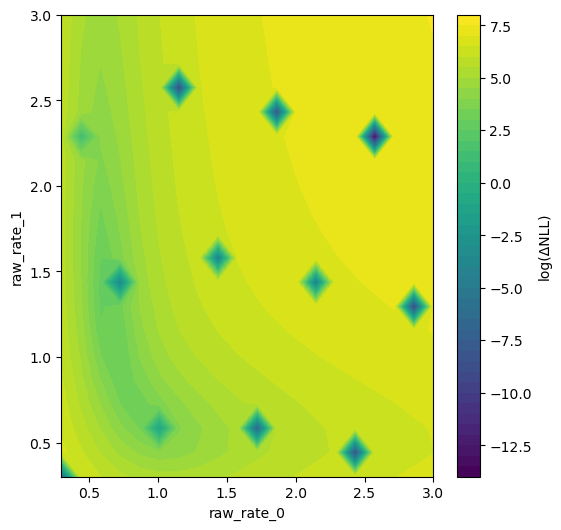

In [ ]:
pset = {
    'raw_rate_0': (0.3, 3, 20),
    'raw_rate_1': (0.3, 3, 20),
}

def model_primitive(x, data):
    model = emm.ExponentialMixtureModel(x, 4, data_mean=data.mean(x), ordered_rates=True)
    return model

df = emm.profile_model(x, model_primitive, data, pset)
fig, axes = emm.plot_pair_profiles(df, pset, plot_contours=False,)

Fitted in 3.93 seconds
Fit status: 61, covQual: 2
NLL: 31030.826118613342


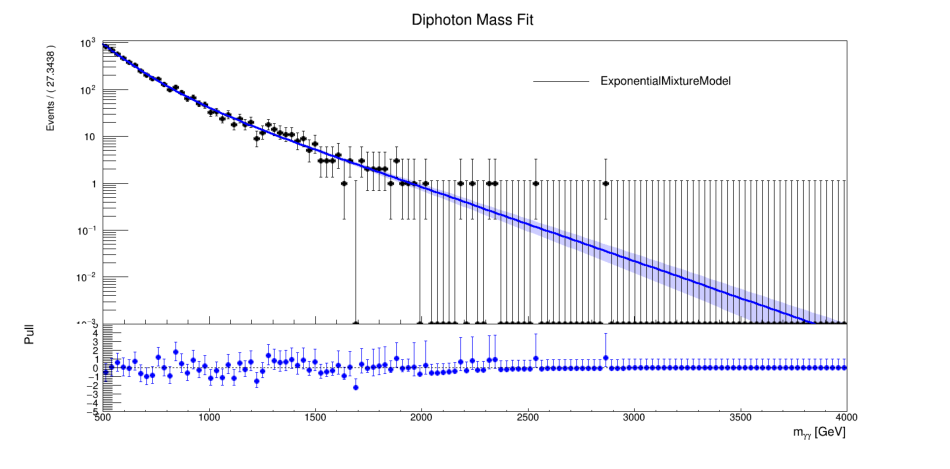

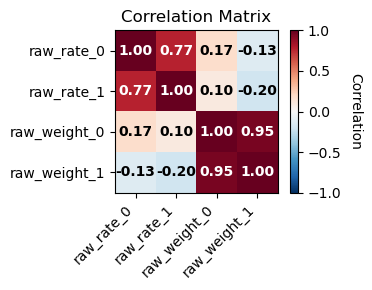

Model: ExponentialMixtureModel
raw_rate_0: 0.6421875055448736 + 0.045835781482928876 -0.04747277848846428
raw_rate_1: 1.5351937050025353 + 0.12212653690754992 -0.10090981035869982
raw_weight_0: -0.2344040654823145 + 0.9181202451223578 -0.9181202451223578
raw_weight_1: 0.23440407429504936 + 0.9224537011357479 -0.9224537011357479
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
Minuit2Minimizer: Minimize with max-calls 2000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31030.8261188275355
Edm   = 2.82045687695358396e-07
Nfcn  = 142
raw_rate_0	  = 0.642192	 +/-  0.0450565	(limited)
raw_rate_1	  = 1.5352	 +/-  0.107896	(limited)
raw_weight_0	  = -0.234418	 +/-  0.918135
raw_weight_1	  = 0.234418	 +/-  0.922472
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to cal

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31217.34498 Edm =       578.8513163 NCalls =     17
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31217.34498
  Edm           : 578.8513163
  Internal parameters:	[     -1.370461484     -1.287002218                0                0]	
  Internal gradient  :	[       9877.32899      2336.935353     -198.7099488      198.7099488]	
  Internal covariance matrix:
[[  7.6522164e-06              0              0              0]
 [              0  0.00012354344              0              0]
 [              0              0    0.011322329              0]
 [              0              0              0    0.011322329]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 2000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31217.34498 Edm =       578.8513163 NCalls =     17

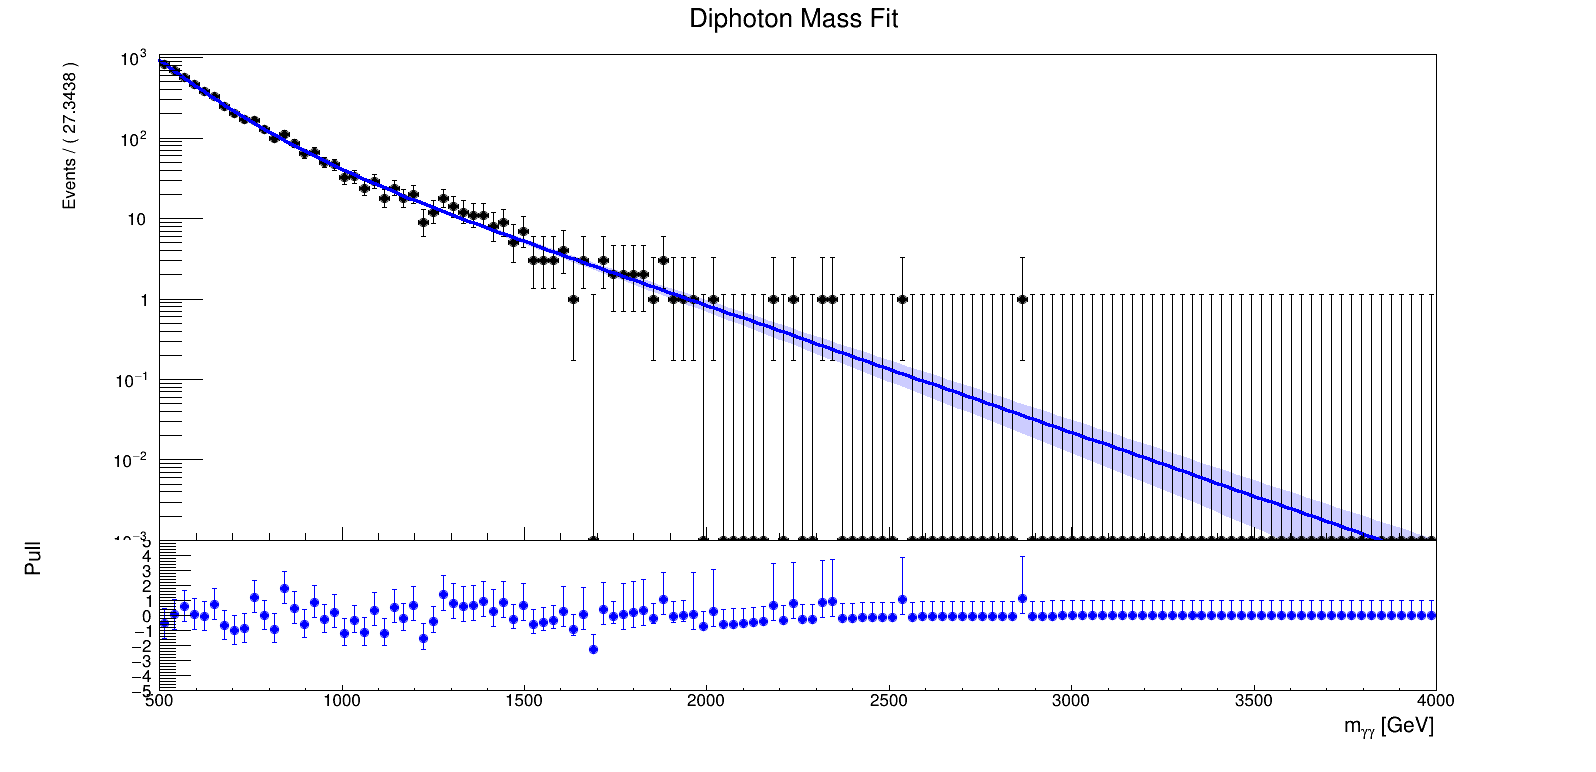

In [4]:
model_2 = emm.ExponentialMixtureModel(x, 2, data_mean=data.mean(x), use_normalization_construction=True)
emm.fit_and_plot(model_2, data, x, minos=True)

Plotting raw_rate_2 vs raw_rate_3 on axes (0, 0)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Exponen

Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a default constructor before attempting to read it.
Warning in <TBufferFile::WriteObjectAny>: since RooNLLVar has no public constructor
	which can be called without argument, objects of this class
	can not be read with the current library. You will need to
	add a de

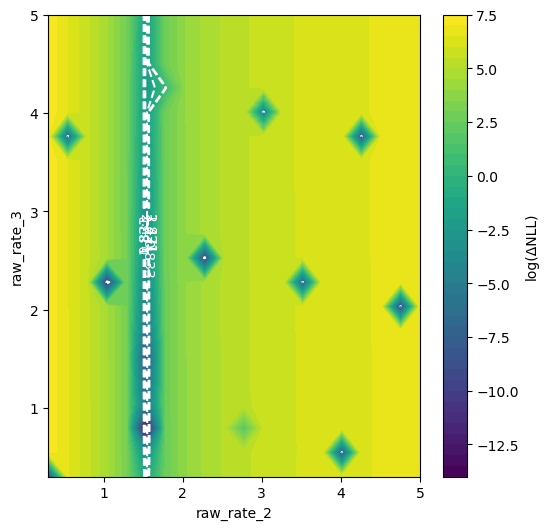

In [5]:
pset = {
    # 'raw_rate_0': (0.01, 5, 20),
    # 'raw_rate_1': (0.3, 2.5, 20),
    'raw_rate_2': (0.3, 5, 20),
    'raw_rate_3': (0.3, 5, 20)
}

model_2_params = {}
for i in range(model_2.n_components):
    r = model_2.raw_rates[i]
    r_nominal = r.getVal()
    r_up = r.getErrorHi()
    r_down = r.getErrorLo()
    model_2_params[f'raw_rate_{i}'] = (r_nominal, r_nominal-r_down, r_nominal+r_up)

def model_primitive(x, data):
    model = emm.ExponentialMixtureModel(x, 4, data_mean=data.mean(x), use_normalization_construction=True, **model_2_params)
    return model

df = emm.profile_model(x, model_primitive, data, pset)
fig, axes = emm.plot_pair_profiles(df, pset)

In [16]:
#print the minimum
print("Minimum value of the model:", df['nll'].min())
print(f"Parameters at minimum: \n{df.loc[df['nll'].idxmin()]}")
    

Minimum value of the model: 31030.83470625248
Parameters at minimum: 
raw_rate_0        0.535000
raw_rate_1        1.458000
raw_rate_2        0.647000
raw_rate_3        1.574000
nll           31030.834706
Name: 20071, dtype: float64


In [22]:
#print the minimum
print("Minimum value of the model:", df['nll'].min())
print(f"Parameters at minimum: \n{df.loc[df['nll'].idxmin()]}")

Minimum value of the model: 31030.827500345225
Parameters at minimum: 
raw_rate_2        1.5410
raw_rate_3        1.5410
nll           31030.8275
Name: 902, dtype: float64


In [ ]:

grid = np.linspace(0, 10, 100)

def fit_model(supports):
    model = emm.ExponentialMixtureModel(x, len(supports), data_mean=data.mean(x), use_normalization_construction=True)
    for i, support in enumerate(supports):
        model.raw_rates[i].setVal(support)
        model.raw_rates[i].setConstant(True)
    
    model.pdf.fitTo(data)
    weights = [p.getVal() for p in model.weights]

    nll = model.pdf.createNLL(data)
    return {
        "nll": nll.getVal(),
        "weights": weights,
        "supports": supports
    }

# Randomly search through the parameter space, if a new nll is found 

NameError: name 'np' is not defined

In [ ]:
""